In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt



import sys
sys.path.insert(0, '/home/cosweeney/code/EmulateLSS')
from train_nn_emu import train_emu 
from emulator import Emulator

import yaml

with open('emulatelss_training.yaml') as f:
    config = yaml.safe_load(f)

OUT_DIR = '/spiffball/cosweeney/data/training/compact_multipole_training_set/z0p5/'
ELLS = (0, 2, 4)
N_TEST = 5_000


thetas = np.load(OUT_DIR + 'thetas_train.npy')
xi     = np.load(OUT_DIR + 'xi_train.npy')
s      = np.load(OUT_DIR + 's.npy')

print(thetas.shape, xi.shape, s.shape)
print(f"s: [{s.min():.1f}, {s.max():.1f}] in {len(s)} bins")

I0000 00:00:1788552075.721161 1873293 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788552075.722623 1873293 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788552075.781606 1873293 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788552077.492357 1873293 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

(50000, 6) (50000, 3, 156) (156,)
s: [16.0, 171.0] in 156 bins


In [2]:
with h5py.File(OUT_DIR + 'train.h5', 'r') as f:
    params = f['params'][:]          # (N, 6)
    xi0 = f['xi0'][:]                # (N, n_s)
    xi2, xi4 = f['xi2'][:], f['xi4'][:]
    s = f['s'][:]

test = np.load(OUT_DIR + 'test.npz')
params_test, xi_test, s = test['params'], test['xi'], test['s']

val = np.load(OUT_DIR + 'val.npz')
params_val, xi_val = val['params'], val['xi']

In [6]:
# latest
Ftrain = xi0                          # or xi2 / xi4, one multipole at a time
Fstd = np.std(Ftrain, axis=0)
Ftrain_asinh = np.arcsinh(Ftrain / Fstd)

Fval = xi_val[:, 0]                   # match whichever ell Ftrain is
Fval_asinh = np.arcsinh(Fval / Fstd)  # same Fstd as train -- do not recompute per-set

Pmean, Pstd = params.mean(0), params.std(0)
Ptrain = (params - Pmean) / Pstd
Pval = (params_val - Pmean) / Pstd    # same Pmean/Pstd as train

In [ ]:
# old
Ftrain = xi0[:, ::4] # we compute more points than we may need in practice. 
Fstd = np.std(Ftrain, axis=0)
Ftrain = np.arcsinh(Ftrain/Fstd) # scale inputs so taht everything is at a similar scale

Pmean = np.mean(params, axis=0)
Pstd = np.std(params, axis=0)
Ptrain = (params - Pmean)/Pstd

In [ ]:
# old
output_path = '/spiffball/cosweeney/data/models/'

emu = train_emu(Ptrain, Ftrain, validation_frac=0.08, n_hidden=config['n_hidden'], n_pcs=xi0[:, ::4].shape[-1], n_epochs=config['n_epochs'],
                fstd=Fstd, pmean=Pmean, pstd=Pstd, outfile=output_path+'compact_xi0_z0p5', lrs=config['learning_rate'], nbatchs=config['nbatchs'])   

Using learning rate, batch size:  1.00e-02, 320.
Epoch 1/1000


E0000 00:00:1787781804.196294 3146555 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


168/168 - 2s - loss: 158881.6875 - mse: 158881.6875 - val_loss: 9061.4902 - val_mse: 9061.4902 - 2s/epoch - 13ms/step
Epoch 2/1000
168/168 - 1s - loss: 6091.0024 - mse: 6091.0024 - val_loss: 4473.7861 - val_mse: 4473.7861 - 540ms/epoch - 3ms/step
Epoch 3/1000
168/168 - 1s - loss: 3273.6062 - mse: 3273.6062 - val_loss: 2635.6304 - val_mse: 2635.6301 - 535ms/epoch - 3ms/step
Epoch 4/1000
168/168 - 1s - loss: 2102.5344 - mse: 2102.5344 - val_loss: 1766.6594 - val_mse: 1766.6594 - 555ms/epoch - 3ms/step
Epoch 5/1000
168/168 - 1s - loss: 1477.8589 - mse: 1477.8589 - val_loss: 1281.7316 - val_mse: 1281.7316 - 542ms/epoch - 3ms/step
Epoch 6/1000
168/168 - 1s - loss: 1095.0739 - mse: 1095.0739 - val_loss: 981.7572 - val_mse: 981.7572 - 541ms/epoch - 3ms/step
Epoch 7/1000
168/168 - 1s - loss: 849.6625 - mse: 849.6625 - val_loss: 774.8726 - val_mse: 774.8726 - 552ms/epoch - 3ms/step
Epoch 8/1000
168/168 - 1s - loss: 678.8815 - mse: 678.8815 - val_loss: 630.2133 - val_mse: 630.2133 - 533ms/epoch 

In [4]:
from train_nn_emu import Emulator
from tensorflow.keras.callbacks import EarlyStopping

def train_emu_with_val(Ptrain, Ftrain_asinh, Pval, Fval_asinh,
                        n_hidden, n_pcs, n_epochs, fstd, pmean, pstd,
                        outfile, lrs, nbatchs, restart_file=None):
    mean = np.mean(Ftrain_asinh, axis=0).astype('float32')
    sigmas = np.std(Ftrain_asinh, axis=0).astype('float32')
    Ftrain_n = (Ftrain_asinh - mean) / sigmas
    Fval_n = (Fval_asinh - mean) / sigmas    # same mean/sigmas as train -- never recomputed on val

    cov_matrix = np.cov(Ftrain_n.T)
    w, v = np.linalg.eigh(cov_matrix)
    w, v = np.flip(w), np.flip(v, axis=1).astype('float32')
    pc_train = Ftrain_n @ v
    pc_mean, pc_sigmas = pc_train.mean(0), pc_train.std(0)

    emulator = Emulator(n_params=Ptrain.shape[-1], nks=Ftrain_n.shape[-1],
                        pc_sigmas=pc_sigmas, pc_mean=pc_mean, v=v,
                        sigmas=sigmas, mean=mean, fstd=fstd,
                        param_mean=pmean, param_sigmas=pstd,
                        n_components=n_pcs, n_hidden=n_hidden)
    if restart_file is not None:
        emulator.load(restart_file)

    emulator.compile(optimizer='adam', loss='mse', metrics=['mse'])
    es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=1_000)

    for lr, nbatch in zip(lrs, nbatchs):
        print("Using learning rate, batch size:  %.2e, %d." % (lr, nbatch))
        emulator.optimizer.learning_rate.assign(lr)
        emulator.fit(Ptrain, Ftrain_n, epochs=n_epochs, batch_size=nbatch,
                     validation_data=(Pval, Fval_n), callbacks=[es], verbose=2)
        if outfile is not None:
            emulator.save(outfile)
    return emulator

In [8]:
# new
output_path = '/spiffball/cosweeney/data/models/'

emu = train_emu_with_val(Ptrain, Ftrain_asinh, Pval, Fval_asinh,
                         n_hidden=config['n_hidden'], n_pcs=Ftrain.shape[-1],
                         n_epochs=config['n_epochs'], fstd=Fstd,
                         pmean=Pmean, pstd=Pstd,
                         outfile=output_path + 'compact_xi0_z0p5',
                         lrs=config['learning_rate'], nbatchs=config['nbatchs'])

Using learning rate, batch size:  1.00e-02, 320.
Epoch 1/1000


E0000 00:00:1788375358.123799   87372 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


156/156 - 2s - loss: 100670.7891 - mse: 100670.7891 - val_loss: 6071.7939 - val_mse: 6071.7939 - 2s/epoch - 15ms/step
Epoch 2/1000
156/156 - 1s - loss: 4195.8325 - mse: 4195.8325 - val_loss: 2935.3274 - val_mse: 2935.3274 - 622ms/epoch - 4ms/step
Epoch 3/1000
156/156 - 1s - loss: 2323.5579 - mse: 2323.5579 - val_loss: 1857.1713 - val_mse: 1857.1713 - 615ms/epoch - 4ms/step
Epoch 4/1000
156/156 - 1s - loss: 1520.0168 - mse: 1520.0168 - val_loss: 1278.9156 - val_mse: 1278.9156 - 622ms/epoch - 4ms/step
Epoch 5/1000
156/156 - 1s - loss: 1078.3662 - mse: 1078.3662 - val_loss: 923.8109 - val_mse: 923.8109 - 621ms/epoch - 4ms/step
Epoch 6/1000
156/156 - 1s - loss: 807.5677 - mse: 807.5677 - val_loss: 713.9745 - val_mse: 713.9744 - 622ms/epoch - 4ms/step
Epoch 7/1000
156/156 - 1s - loss: 628.5736 - mse: 628.5736 - val_loss: 578.7670 - val_mse: 578.7670 - 619ms/epoch - 4ms/step
Epoch 8/1000
156/156 - 1s - loss: 500.9602 - mse: 500.9602 - val_loss: 450.1544 - val_mse: 450.1544 - 613ms/epoch - 4m

In [10]:
print(len(emu.trainable_variables))

18


In [6]:
emu = Emulator(output_path+'compact_xi0_z0p5')

In [7]:
nsample = Ftrain.shape[0]
val_frac = 0.08

Pval = params[int(nsample*val_frac):]
Fval = xi0[int(nsample*val_frac):, ::4]
_, Fpred = emu(Pval)

In [8]:
from compact.config import Config
cfg = Config()

In [38]:
Fstd.shape

()

In [17]:
Fpred.shape[0]//2

29175

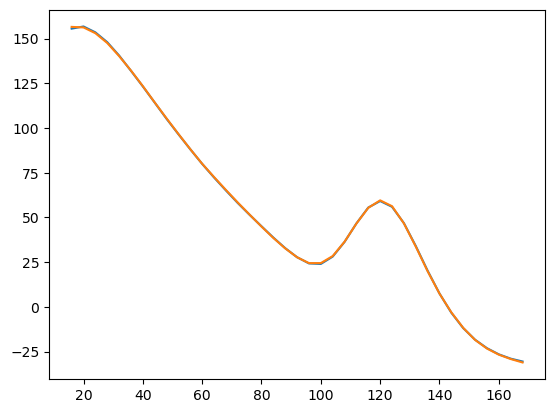

In [9]:
r_plot = s[::4]

ind = 1000

plt.plot(r_plot, r_plot**2*Fval[ind])
plt.plot(r_plot, (r_plot**2*Fpred[ind]))

# plt.ylim((-75, 200))

(-10.0, 200.0)

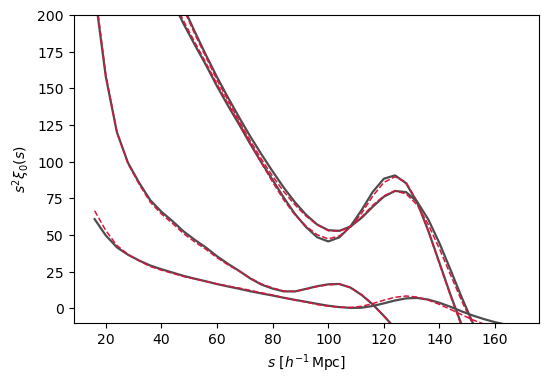

In [25]:
Pval = params_test
Fval = xi_test[:, 0, ::4]     # ell=0 slice, same decimation as training
r_plot = s[::4]

_, Fpred = emu(Pval)

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(4):
    ax.plot(r_plot, r_plot**2 * Fval[i], color='0.3', lw=1.6)
    ax.plot(r_plot, r_plot**2 * Fpred[i], color='crimson', lw=1.1, ls='--')
ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
ax.set_ylabel(r'$s^2\xi_0(s)$')
ax.set_ylim((-10, 200))

In [26]:
print(emu.n_layers, emu.n_components, emu.nk)
print(np.abs(np.array(emu.W[-1])).max())   # sane weights are O(1), not huge

5 39 39
11.793841


In [10]:
p0err = (Fpred - Fval)/Fval

In [22]:
np.percentile(p0err, [68], axis=0)[0].shape

(39,)

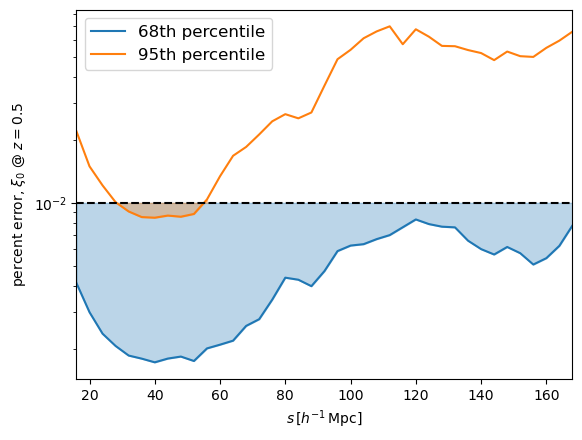

In [28]:
plt.plot(r_plot, np.percentile(p0err, [68, 95], axis=0).T)
plt.xlabel(r'$s \, [h^{-1}\, \rm Mpc]$')
plt.ylabel(r'percent error, $\xi_0$ @ $z=0.5$')
# plt.ylim([2e-5, 5e-1])
plt.yscale('log')


mask = np.percentile(p0err, [95], axis=0)[0] < 1.05e-2
plt.fill_between(r_plot, np.percentile(p0err, [68], axis=0)[0], 1e-2, color='C0', alpha=0.3)
plt.fill_between(r_plot[mask], np.percentile(p0err, [95], axis=0)[0][mask], 1e-2, color='C1', alpha=0.3)


plt.axhline(1e-2, ls='--', c='k')
plt.margins(x=0)

plt.legend(['68th percentile', '95th percentile'], fontsize=12)
plt.subplots_adjust(wspace=0.1, hspace=0.0)

In [29]:
p0err.shape

(53682, 39)

In [30]:
xi_test.shape

(5000, 3, 156)

/tmp/ipykernel_3146555/3350435141.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


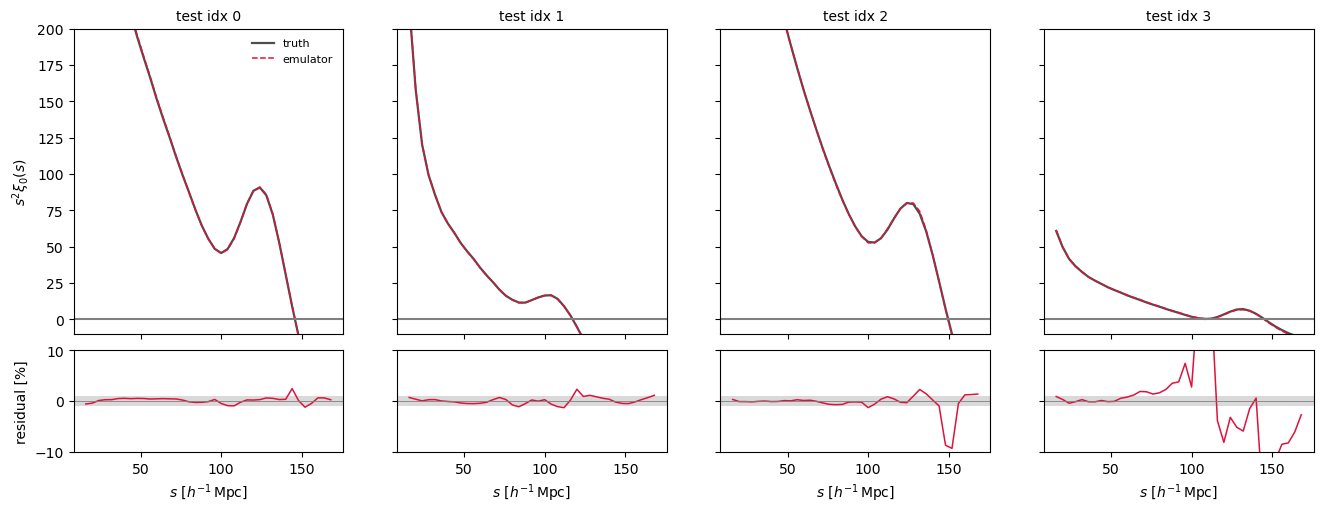

In [31]:
Pval = params_test
Fval = xi_test[:, 0, ::4]     # ell=0 slice, same decimation as training
r_plot = s[::4]

_, Fpred = emu(Pval)          # emulator.py's class already applies sinh() internally

frac_pct = 100 * (Fpred - Fval) / np.abs(Fval)   # fractional error, as a percentage

fig, axes = plt.subplots(2, 4, figsize=(16, 5.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})
for col in range(4):
    top, bot = axes[0, col], axes[1, col]

    top.plot(r_plot, r_plot**2 * Fval[col], color='0.3', lw=1.6, label='truth')
    top.plot(r_plot, r_plot**2 * Fpred[col], color='crimson', lw=1.1, ls='--', label='emulator')
    top.set_ylim(-10, 200)
    top.set_title(fr'test idx {col}', fontsize=10)
    top.axhline(0, color='grey')

    bot.plot(r_plot, frac_pct[col], color='crimson', lw=1.1)
    bot.axhline(0, color='0.5', lw=0.6)
    bot.axhspan(-1, 1, color='0.85', lw=0)   # 1% band, for reference against the paper's plot
    # bot.axhspan(-5, 5, color='0.5', lw=0)   
    # bot.axhspan(-10, 10, color='0.3', lw=0)   
    


    bot.set_ylim(-10, 10)
    bot.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')

    if col:
        top.set_yticklabels([]); bot.set_yticklabels([])

axes[0, 0].set_ylabel(r'$s^2\xi_0(s)$')
axes[1, 0].set_ylabel(r'residual [%]')
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()

/tmp/ipykernel_1281868/1578254405.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


idx 1345: median |resid| 0.081%  max 100.003%
idx 2549: median |resid| 0.063%  max 0.953%
idx 4241: median |resid| 0.165%  max 5.375%
idx 3176: median |resid| 0.112%  max 9.205%


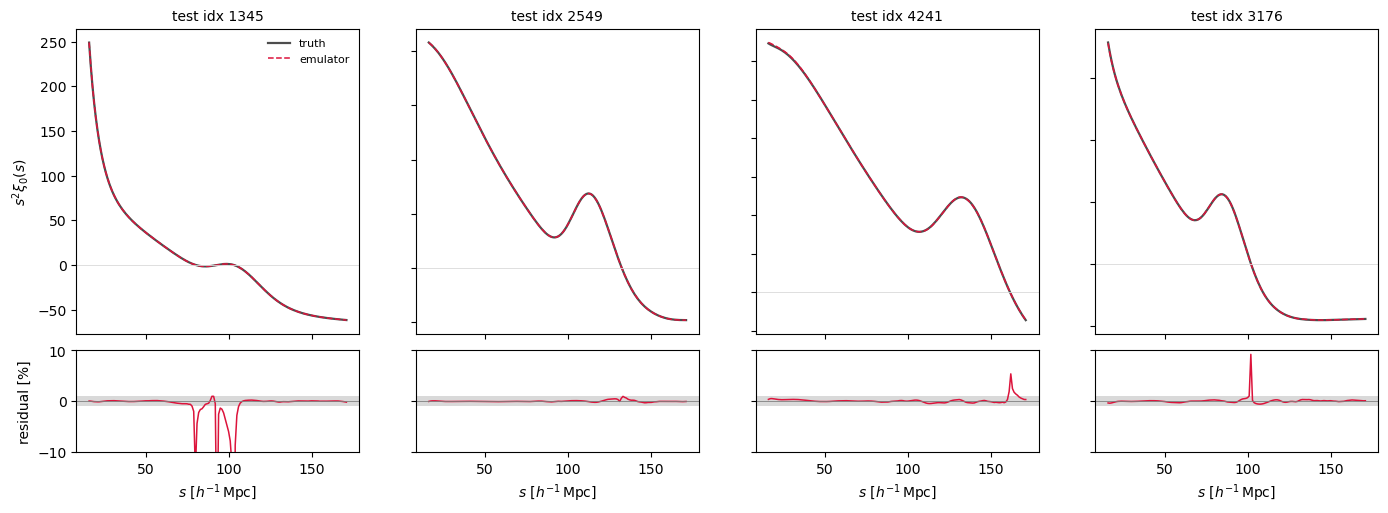

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from emulator import Emulator as InferenceEmulator

emu_xi0 = InferenceEmulator(output_path + 'compact_xi0_z0p5')

n_show = 4
rng = np.random.default_rng(0)
idx = rng.choice(len(params_test), n_show, replace=False)

_, Fpred = emu_xi0(params_test[idx])      # already in physical xi_0 units; ignore first return (bogus k array)
Ftruth = xi_test[idx, 0]                  # ell=0 slice

frac_pct = 100 * (Fpred - Ftruth) / np.abs(Ftruth)

fig, axes = plt.subplots(2, n_show, figsize=(4.2 * n_show, 5.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})
for col in range(n_show):
    top, bot = axes[0, col], axes[1, col]

    top.plot(s, s**2 * Ftruth[col], color='0.3', lw=1.6, label='truth')
    top.plot(s, s**2 * Fpred[col], color='crimson', lw=1.1, ls='--', label='emulator')
    top.axhline(0, color='0.85', lw=0.6)
    top.set_title(f'test idx {idx[col]}', fontsize=10)

    bot.plot(s, frac_pct[col], color='crimson', lw=1.1)
    bot.axhline(0, color='0.5', lw=0.6)
    bot.axhspan(-1, 1, color='0.85', lw=0)     # 1% reference band, per Figure 3
    bot.set_ylim(-10, 10)
    bot.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')

    if col:
        top.set_yticklabels([]); bot.set_yticklabels([])

axes[0, 0].set_ylabel(r'$s^2\xi_0(s)$')
axes[1, 0].set_ylabel('residual [%]')
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()

for i, f in zip(idx, frac_pct):
    print(f"idx {i}: median |resid| {np.median(np.abs(f)):.3f}%  "
          f"max {np.abs(f).max():.3f}%")

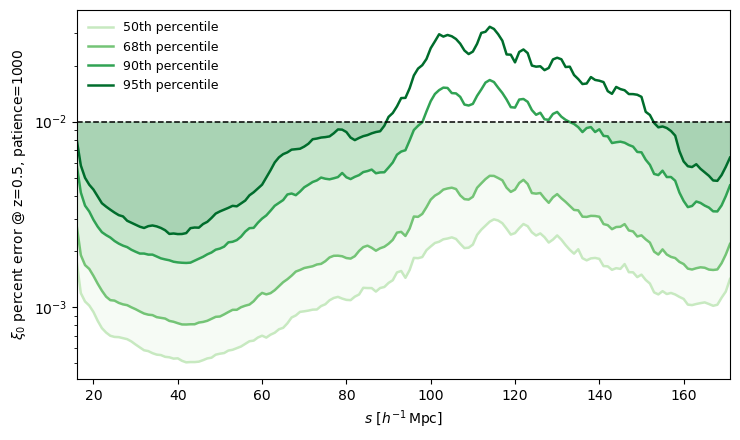

In [20]:
Pval = params_test
Fval = xi_test[:, 0]           # ell=0, full s grid -- no decimation
_, Fpred = emu_xi0(Pval)

frac =  np.abs(Fval - Fpred) / np.abs(Fval)   # (n_test, n_s), percent
pcts = [50, 68, 90, 95]
curves = {p: np.percentile(frac, p, axis=0) for p in pcts}

fig, ax = plt.subplots(figsize=(7.5, 4.5))

line_c = {50: '#c7e9c0', 68: '#74c476', 90: '#31a354', 95: '#006d2c'}
for p in pcts:
    c = curves[p]
    ax.plot(s, c, color=line_c[p], lw=1.8, label=f'{p}th percentile')
    # fill the gap down to the 1% line, only where this curve is actually below it
    ax.fill_between(s, c, 1e-2, where=(c < 1e-2), color=line_c[p], alpha=0.15, lw=0)

ax.axhline(1e-2, color='k', ls='--', lw=1.1)
ax.set_yscale('log')
#ax.set_ylim(max(1e-3, np.nanmin(list(curves.values())) * 0.5), 100)
ax.set_xlim(s.min(), s.max())
ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
ax.set_ylabel(r'$\xi_0$ percent error @ z=0.5, patience=1000')
ax.legend(frameon=False, fontsize=9, loc='upper left')
fig.tight_layout()

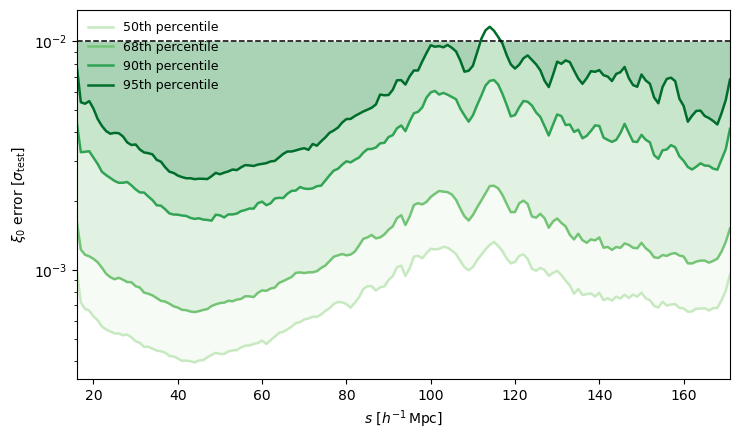

In [17]:
sigma_s = np.std(Fval, axis=0)              # per-bin scatter across the test set, (n_s,)
resid_sigma = (Fpred - Fval) / sigma_s      # (n_test, n_s), in units of sigma
frac_sigma = np.abs(resid_sigma)

curves = {p: np.percentile(frac_sigma, p, axis=0) for p in pcts}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for p in pcts:
    c = curves[p]
    ax.plot(s, c, color=line_c[p], lw=1.8, label=f'{p}th percentile')
    ax.fill_between(s, c, 0.01, where=(c < 0.01), color=line_c[p], alpha=0.15, lw=0)

ax.axhline(0.01, color='k', ls='--', lw=1.1)   # whatever threshold plays the role of "1%" here
ax.set_yscale('log')
ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
ax.set_ylabel(r'$\xi_0$ error [$\sigma_{\rm test}$]')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.margins(x=0)
fig.tight_layout()

In [25]:
# let's try the quad
Ftrain_xi2 = xi2                          # full s grid, no decimation
Fstd_xi2 = np.std(Ftrain_xi2, axis=0)
Ftrain_xi2_asinh = np.arcsinh(Ftrain_xi2 / Fstd_xi2)

Fval_xi2 = xi_val[:, 1]                   # ell=2 slice of val's (N, 3, n_s)
Fval_xi2_asinh = np.arcsinh(Fval_xi2 / Fstd_xi2)   # same Fstd_xi2 as train

# params/Ptrain/Pval/Pmean/Pstd are unchanged from the xi_0 run -- theta
# doesn't depend on which multipole is being emulated, so reuse them directly
emu_xi2 = train_emu_with_val(Ptrain, Ftrain_xi2_asinh, Pval, Fval_xi2_asinh,
                             n_hidden=config['n_hidden'], n_pcs=Ftrain_xi2.shape[-1],
                             n_epochs=config['n_epochs'], fstd=Fstd_xi2,
                             pmean=Pmean, pstd=Pstd,
                             outfile=output_path + 'compact_xi2_z0p5',
                             lrs=config['learning_rate'], nbatchs=config['nbatchs'])

Using learning rate, batch size:  1.00e-02, 320.
Epoch 1/1000
156/156 - 2s - loss: 140373.2812 - mse: 140373.2812 - val_loss: 7740.0947 - val_mse: 7740.0947 - 2s/epoch - 13ms/step
Epoch 2/1000
156/156 - 1s - loss: 5457.5059 - mse: 5457.5059 - val_loss: 4004.1838 - val_mse: 4004.1838 - 710ms/epoch - 5ms/step
Epoch 3/1000
156/156 - 1s - loss: 3109.1055 - mse: 3109.1055 - val_loss: 2548.7764 - val_mse: 2548.7761 - 709ms/epoch - 5ms/step
Epoch 4/1000
156/156 - 1s - loss: 2100.7188 - mse: 2100.7188 - val_loss: 1769.9495 - val_mse: 1769.9495 - 683ms/epoch - 4ms/step
Epoch 5/1000
156/156 - 1s - loss: 1541.3342 - mse: 1541.3342 - val_loss: 1380.4519 - val_mse: 1380.4519 - 766ms/epoch - 5ms/step
Epoch 6/1000
156/156 - 1s - loss: 1184.0963 - mse: 1184.0963 - val_loss: 1060.2200 - val_mse: 1060.2200 - 765ms/epoch - 5ms/step
Epoch 7/1000
156/156 - 1s - loss: 935.5883 - mse: 935.5883 - val_loss: 871.3856 - val_mse: 871.3856 - 763ms/epoch - 5ms/step
Epoch 8/1000
156/156 - 1s - loss: 757.8075 - mse: 

/tmp/ipykernel_1281868/1413807068.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


idx 1345: median |resid| 0.046%  max 0.187%
idx 2549: median |resid| 0.028%  max 0.119%
idx 4241: median |resid| 0.030%  max 0.166%
idx 3176: median |resid| 0.034%  max 0.157%


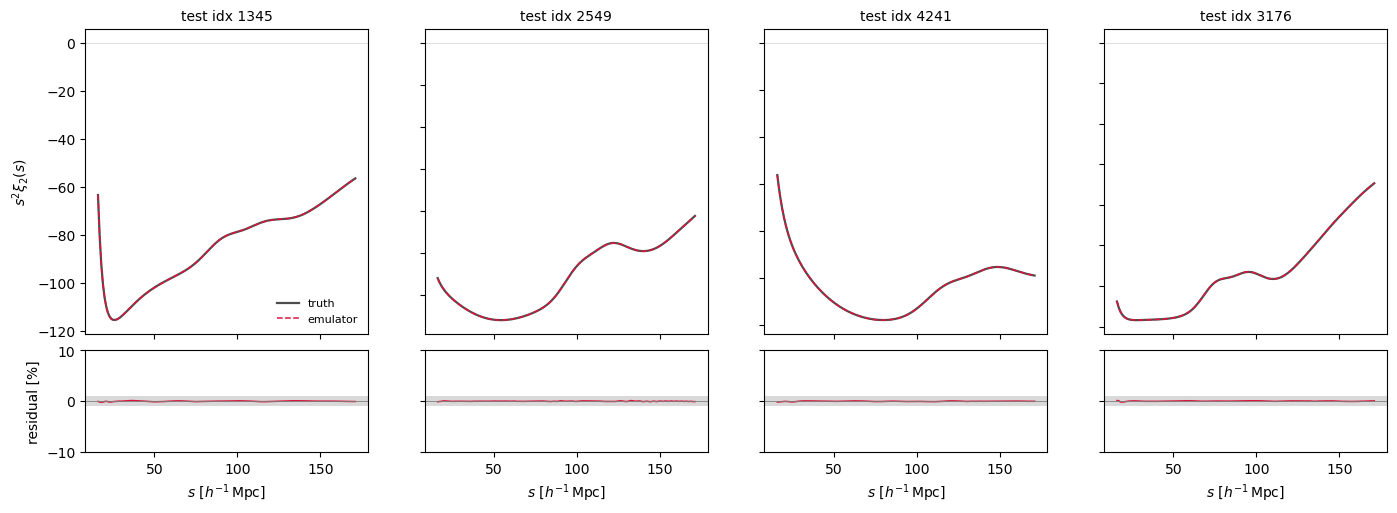

In [17]:
emu_xi2 = InferenceEmulator(output_path + 'compact_xi2_z0p5')

n_show = 4
rng = np.random.default_rng(0)
idx = rng.choice(len(params_test), n_show, replace=False)

_, Fpred_xi2 = emu_xi2(params_test[idx])      # already in physical xi_0 units; ignore first return (bogus k array)
Ftruth_xi2 = xi_test[idx, 1]                  # ell=2 slice

frac_pct = 100 * (Fpred_xi2 - Ftruth_xi2) / np.abs(Ftruth_xi2)

fig, axes = plt.subplots(2, n_show, figsize=(4.2 * n_show, 5.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})
for col in range(n_show):
    top, bot = axes[0, col], axes[1, col]

    top.plot(s, s**2 * Ftruth_xi2[col], color='0.3', lw=1.6, label='truth')
    top.plot(s, s**2 * Fpred_xi2[col], color='crimson', lw=1.1, ls='--', label='emulator')
    top.axhline(0, color='0.85', lw=0.6)
    top.set_title(f'test idx {idx[col]}', fontsize=10)

    bot.plot(s, frac_pct[col], color='crimson', lw=1.1)
    bot.axhline(0, color='0.5', lw=0.6)
    bot.axhspan(-1, 1, color='0.85', lw=0)     # 1% reference band, per Figure 3
    bot.set_ylim(-10, 10)
    bot.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')

    if col:
        top.set_yticklabels([]); bot.set_yticklabels([])

axes[0, 0].set_ylabel(r'$s^2\xi_2(s)$')
axes[1, 0].set_ylabel('residual [%]')
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()

for i, f in zip(idx, frac_pct):
    print(f"idx {i}: median |resid| {np.median(np.abs(f)):.3f}%  "
          f"max {np.abs(f).max():.3f}%")

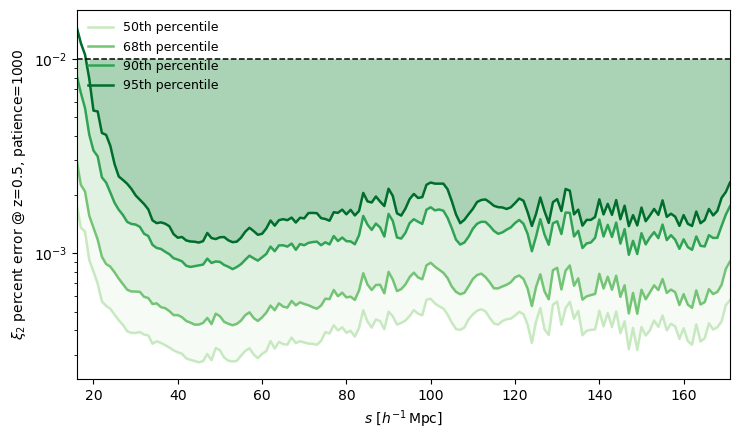

In [28]:
Pval = params_test
Fval_xi2 = xi_test[:, 1]           # ell=0, full s grid -- no decimation
_, Fpred_xi2 = emu_xi2(Pval)

frac =  np.abs(Fval_xi2 - Fpred_xi2) / np.abs(Fval_xi2)   # (n_test, n_s), percent
pcts = [50, 68, 90, 95]
curves = {p: np.percentile(frac, p, axis=0) for p in pcts}

fig, ax = plt.subplots(figsize=(7.5, 4.5))

line_c = {50: '#c7e9c0', 68: '#74c476', 90: '#31a354', 95: '#006d2c'}
for p in pcts:
    c = curves[p]
    ax.plot(s, c, color=line_c[p], lw=1.8, label=f'{p}th percentile')
    # fill the gap down to the 1% line, only where this curve is actually below it
    ax.fill_between(s, c, 1e-2, where=(c < 1e-2), color=line_c[p], alpha=0.15, lw=0)

ax.axhline(1e-2, color='k', ls='--', lw=1.1)
ax.set_yscale('log')
#ax.set_ylim(max(1e-3, np.nanmin(list(curves.values())) * 0.5), 100)
ax.set_xlim(s.min(), s.max())
ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
ax.set_ylabel(r'$\xi_2$ percent error @ z=0.5, patience=1000')
ax.legend(frameon=False, fontsize=9, loc='upper left')
fig.tight_layout()

In [8]:
# and now the hexa
output_path = '/spiffball/cosweeney/data/models/'

Ftrain_xi4 = xi4                          # full s grid, no decimation
Fstd_xi4 = np.std(Ftrain_xi4, axis=0)
Ftrain_xi4_asinh = np.arcsinh(Ftrain_xi4 / Fstd_xi4)

Fval_xi4 = xi_val[:, 1]                   # ell=4 slice of val's (N, 3, n_s)
Fval_xi4_asinh = np.arcsinh(Fval_xi4 / Fstd_xi4)   # same Fstd_xi4 as train

# params/Ptrain/Pval/Pmean/Pstd are unchanged from the xi_0 run -- theta
# doesn't depend on which multipole is being emulated, so reuse them directly
emu_xi4 = train_emu_with_val(Ptrain, Ftrain_xi4_asinh, Pval, Fval_xi4_asinh,
                             n_hidden=config['n_hidden'], n_pcs=Ftrain_xi4.shape[-1],
                             n_epochs=config['n_epochs'], fstd=Fstd_xi4,
                             pmean=Pmean, pstd=Pstd,
                             outfile=output_path + 'compact_xi4_z0p5',
                             lrs=config['learning_rate'], nbatchs=config['nbatchs'])

Using learning rate, batch size:  1.00e-02, 320.
Epoch 1/1000


E0000 00:00:1788486074.232446 1281868 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


156/156 - 2s - loss: 105813.7109 - mse: 105813.7109 - val_loss: 4698.1865 - val_mse: 4698.1865 - 2s/epoch - 15ms/step
Epoch 2/1000
156/156 - 1s - loss: 3382.4590 - mse: 3382.4590 - val_loss: 2454.9907 - val_mse: 2454.9907 - 621ms/epoch - 4ms/step
Epoch 3/1000
156/156 - 1s - loss: 1964.9358 - mse: 1964.9358 - val_loss: 1666.4362 - val_mse: 1666.4362 - 621ms/epoch - 4ms/step
Epoch 4/1000
156/156 - 1s - loss: 1349.4016 - mse: 1349.4017 - val_loss: 1358.1692 - val_mse: 1358.1692 - 620ms/epoch - 4ms/step
Epoch 5/1000
156/156 - 1s - loss: 998.5786 - mse: 998.5786 - val_loss: 1061.2733 - val_mse: 1061.2733 - 636ms/epoch - 4ms/step
Epoch 6/1000
156/156 - 1s - loss: 774.3776 - mse: 774.3776 - val_loss: 724.8860 - val_mse: 724.8860 - 629ms/epoch - 4ms/step
Epoch 7/1000
156/156 - 1s - loss: 620.4417 - mse: 620.4417 - val_loss: 623.9613 - val_mse: 623.9613 - 628ms/epoch - 4ms/step
Epoch 8/1000
156/156 - 1s - loss: 506.8317 - mse: 506.8317 - val_loss: 496.2779 - val_mse: 496.2779 - 623ms/epoch - 4m

/tmp/ipykernel_1281868/367147110.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


idx 1345: median |resid| 0.134%  max 0.919%
idx 2549: median |resid| 0.116%  max 0.887%
idx 4241: median |resid| 0.138%  max 1.526%
idx 3176: median |resid| 0.112%  max 1.249%


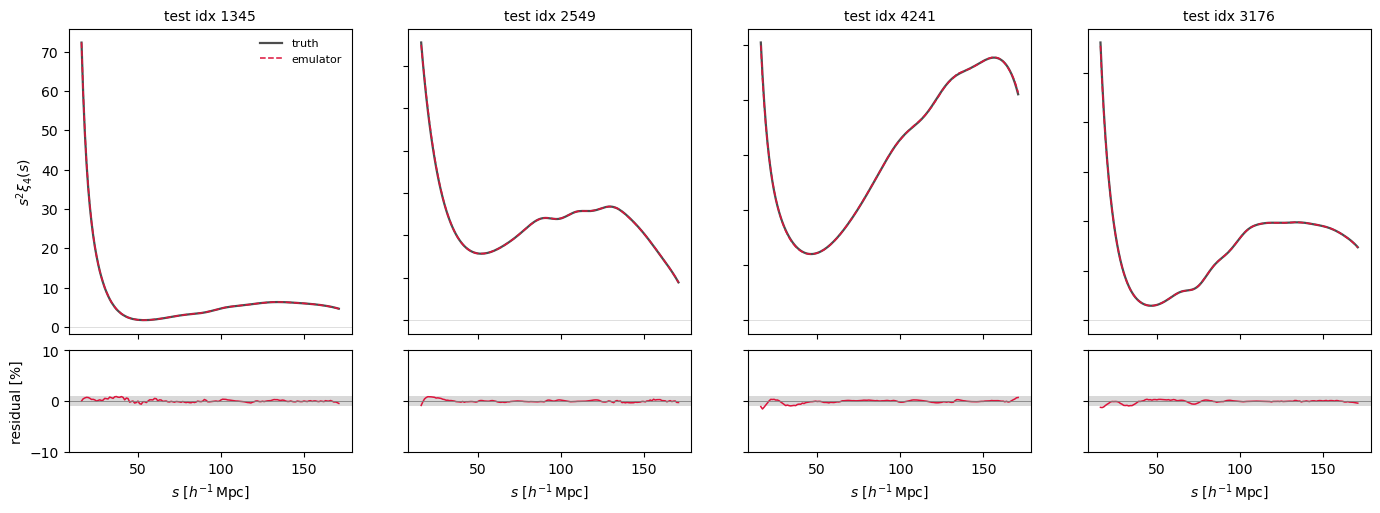

In [13]:
from emulator import Emulator as InferenceEmulator

emu_xi4 = InferenceEmulator(output_path + 'compact_xi4_z0p5')

n_show = 4
rng = np.random.default_rng(0)
idx = rng.choice(len(params_test), n_show, replace=False)

_, Fpred_xi4 = emu_xi4(params_test[idx])      # already in physical xi_0 units; ignore first return (bogus k array)
Ftruth_xi4 = xi_test[idx, 2]                  # ell=4 slice

frac_pct = 100 * (Fpred_xi4 - Ftruth_xi4) / np.abs(Ftruth_xi4)

fig, axes = plt.subplots(2, n_show, figsize=(4.2 * n_show, 5.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})
for col in range(n_show):
    top, bot = axes[0, col], axes[1, col]

    top.plot(s, s**2 * Ftruth_xi4[col], color='0.3', lw=1.6, label='truth')
    top.plot(s, s**2 * Fpred_xi4[col], color='crimson', lw=1.1, ls='--', label='emulator')
    top.axhline(0, color='0.85', lw=0.6)
    top.set_title(f'test idx {idx[col]}', fontsize=10)

    bot.plot(s, frac_pct[col], color='crimson', lw=1.1)
    bot.axhline(0, color='0.5', lw=0.6)
    bot.axhspan(-1, 1, color='0.85', lw=0)     # 1% reference band, per Figure 3
    bot.set_ylim(-10, 10)
    bot.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')

    if col:
        top.set_yticklabels([]); bot.set_yticklabels([])

axes[0, 0].set_ylabel(r'$s^2\xi_4(s)$')
axes[1, 0].set_ylabel('residual [%]')
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()

for i, f in zip(idx, frac_pct):
    print(f"idx {i}: median |resid| {np.median(np.abs(f)):.3f}%  "
          f"max {np.abs(f).max():.3f}%")

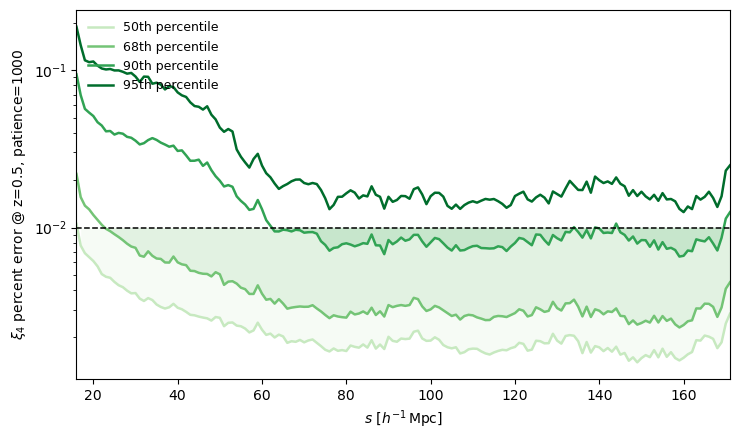

In [16]:
Pval = params_test
Fval_xi4 = xi_test[:, 2]           # ell=4, full s grid -- no decimation
_, Fpred_xi4 = emu_xi4(Pval)

frac =  np.abs(Fval_xi4 - Fpred_xi4) / np.abs(Fval_xi4)   # (n_test, n_s), percent
pcts = [50, 68, 90, 95]
curves = {p: np.percentile(frac, p, axis=0) for p in pcts}

fig, ax = plt.subplots(figsize=(7.5, 4.5))

line_c = {50: '#c7e9c0', 68: '#74c476', 90: '#31a354', 95: '#006d2c'}
for p in pcts:
    c = curves[p]
    ax.plot(s, c, color=line_c[p], lw=1.8, label=f'{p}th percentile')
    # fill the gap down to the 1% line, only where this curve is actually below it
    ax.fill_between(s, c, 1e-2, where=(c < 1e-2), color=line_c[p], alpha=0.15, lw=0)

ax.axhline(1e-2, color='k', ls='--', lw=1.1)
ax.set_yscale('log')
#ax.set_ylim(max(1e-3, np.nanmin(list(curves.values())) * 0.5), 100)
ax.set_xlim(s.min(), s.max())
ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
ax.set_ylabel(r'$\xi_4$ percent error @ z=0.5, patience=1000')
ax.legend(frameon=False, fontsize=9, loc='upper left')
fig.tight_layout()

In [25]:
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20


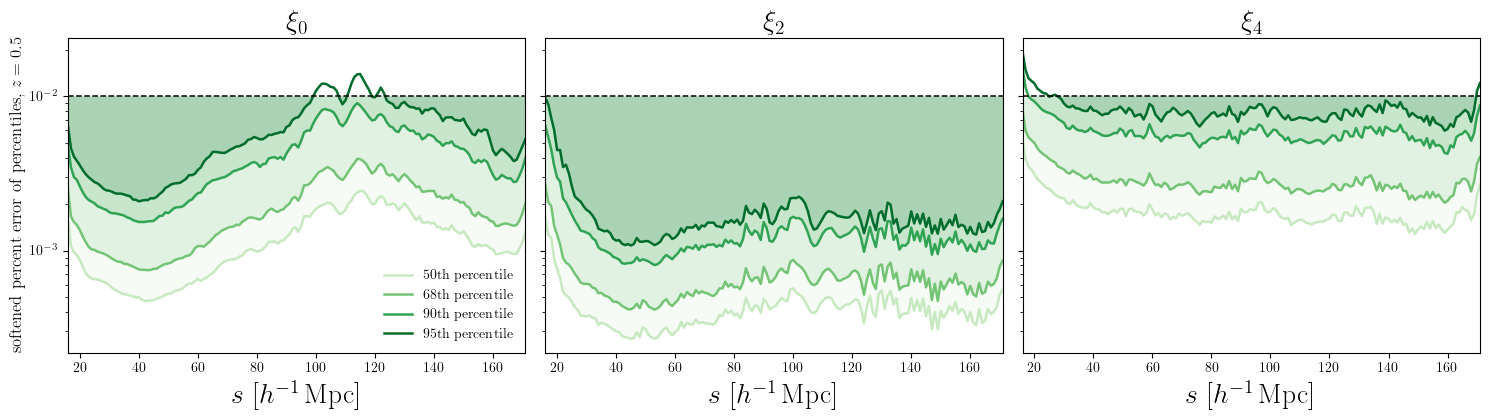

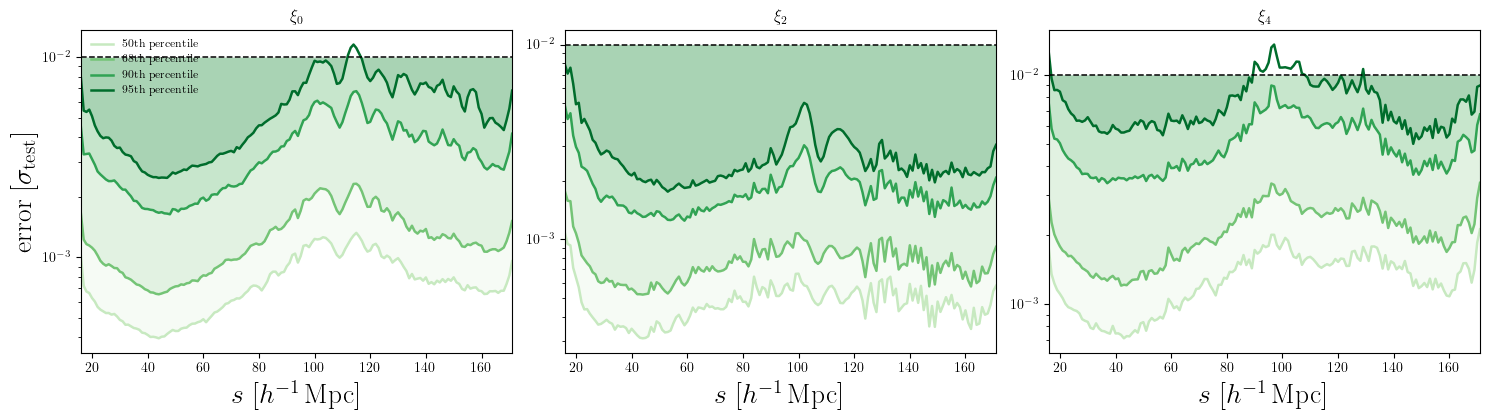

In [37]:
ELLS = (0, 2, 4)
emulators = {0: emu_xi0, 2: emu_xi2, 4: emu_xi4}
pcts = [50, 68, 90, 95]
line_c = {50: '#c7e9c0', 68: '#74c476', 90: '#31a354', 95: '#006d2c'}

def soft_frac_pct(pred, truth, sigma_s, floor=0.1):
    """Percent-like error that floors out near truth's zero crossings
    instead of diverging. floor is in units of sigma_s (the per-bin scatter)."""
    denom = np.sqrt(truth**2 + (floor * sigma_s)**2)
    return np.abs(pred - truth) / denom


preds, truths = {}, {}
for i, l in enumerate(ELLS):
    _, pred = emulators[l](params_test)
    preds[l] = pred
    truths[l] = xi_test[:, i]

# ---------------------------------------------------------------- figure 1: fractional percent
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4.3), sharex=True, sharey=True)
for ax, l in zip(axes1, ELLS):
    sigma_s = np.std(truths[l], axis=0)
    frac = soft_frac_pct(preds[l], truths[l], sigma_s, floor=0.2)
    for p in pcts:
        c = np.percentile(frac, p, axis=0)
        ax.plot(s, c, color=line_c[p], lw=1.8, label=f'{p}th percentile')
        ax.fill_between(s, c, 1e-2, where=(c < 1e-2), color=line_c[p], alpha=0.15, lw=0)
    ax.axhline(1e-2, color='k', ls='--', lw=1.1)
    ax.set_yscale('log')
    ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
    ax.set_title(rf'$\xi_{l}$', fontsize=20)
    ax.margins(x=0)
axes1[0].set_ylabel('softened percent error of percentiles, $z=0.5$', fontsize=12)
axes1[0].legend(frameon=False, fontsize=10, loc='lower right')
fig1.tight_layout()

# ---------------------------------------------------------------- figure 2: scaled by per-bin scatter
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4.3), sharex=True)
for ax, l in zip(axes2, ELLS):
    sigma_s = np.std(truths[l], axis=0)               # per-bin scatter across the test set
    resid = np.abs(preds[l] - truths[l]) / sigma_s
    for p in pcts:
        c = np.percentile(resid, p, axis=0)
        ax.plot(s, c, color=line_c[p], lw=1.8, label=f'{p}th percentile')
        ax.fill_between(s, c, 0.01, where=(c < 0.01), color=line_c[p], alpha=0.15, lw=0)
    ax.axhline(0.01, color='k', ls='--', lw=1.1)
    ax.set_yscale('log')
    ax.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
    ax.set_title(rf'$\xi_{l}$', fontsize=12)
    ax.margins(x=0)
axes2[0].set_ylabel(r'error [$\sigma_{\rm test}$]')
axes2[0].legend(frameon=False, fontsize=8, loc='upper left')
fig2.tight_layout()